<a href="https://colab.research.google.com/github/uvraj3927/Image-Based-Cryptographic-Technique-for-Secure-Color-Image-Communication/blob/main/final_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#reading input
original_path = input("Enter original image path: ")
key_path = input("Enter key image path: ")

img_original = cv2.imread(original_path)
img_key = cv2.imread(key_path)

#validating
if img_original is None:
    raise ValueError("Original image could not be loaded")

if img_key is None:
    raise ValueError("Key image could not be loaded")

Enter original image path: /content/lena.jpeg
Enter key image path: /content/lion.jpeg


In [ ]:
#testing
gray = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)
#cv2_imshow(gray)
print(gray.shape)

rgb_img_orginal = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

print(img_original.shape)
print(img_key.shape)

(520, 520)
(520, 520, 3)
(456, 672, 3)


In [ ]:
def pad_image_to_size(image, target_height, target_width):

    height, width = image.shape[:2]

    if height > target_height or width > target_width:
        raise ValueError(
            f"Image ({height}, {width}) is larger than "
            f"target size ({target_height}, {target_width})"
        )

    pad_top = (target_height - height) // 2
    pad_bottom = target_height - height - pad_top

    pad_left = (target_width - width) // 2
    pad_right = target_width - width - pad_left

    padded_image = cv2.copyMakeBorder(
        image,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        cv2.BORDER_CONSTANT,
        value=0
    )

    return padded_image

#calling the padding funtion
t_h,t_w=img_original.shape[:2]
p_img_key=pad_image_to_size(img_key,t_h,t_w)

#validating
print("before")
print(img_original.shape)
print(img_key.shape)
print("after")
print(rgb_img_orginal.shape,rgb_img_orginal.dtype)
print(p_img_key.shape,p_img_key.dtype)

ValueError: Image (456, 672) is larger than target size (520, 520)

In [ ]:
#resizing key image
def resize_key_image(image, target_height, target_width):

    resized_image = cv2.resize(
        image,
        (target_width, target_height)
    )

    return resized_image

t_h, t_w = img_original.shape[:2]

resized_key = resize_key_image(
    img_key,
    t_h,
    t_w
)                       #funtion call

# Convert resized_key to RGB to match original image format (Bug 2)
rgb_resized_key = cv2.cvtColor(resized_key, cv2.COLOR_BGR2RGB)

print("Original:", img_original.shape)
print("Key:", img_key.shape)
print("Resized key (BGR):", resized_key.shape)
print("Resized key (RGB):", rgb_resized_key.shape, rgb_resized_key.dtype)

Original: (520, 520, 3)
Key: (456, 672, 3)
Resized key (BGR): (520, 520, 3)
Resized key (RGB): (520, 520, 3) uint8


In [ ]:
#XOR op
import time

start_time = time.time()   #start timer

# Use rgb_resized_key for XOR operation (Bug 3)
img_xor = np.bitwise_xor(rgb_img_orginal, rgb_resized_key)

#rotating the pixel value (left and right shift and ored)
# Renamed p_img_key to key_for_rotation_param to avoid variable overwrite (Bug 1)
key_for_rotation_param = img_key.astype(np.uint64)
pixel_sum = np.sum(key_for_rotation_param.astype(np.uint64)) # Use the new variable
N = (pixel_sum % 7) + 1

#img_rotated_pixel = ((img_xor << N) | (img_xor >> (8 - N))).astype(np.uint8)

img_xor16 = img_xor.astype(np.uint16)

img_rotated= ((img_xor16 << N) | (img_xor16 >> (8 - N))) & 0xFF
img_encrypted= img_rotated.astype(np.uint8)

#timer related
encryption_time = (time.time() - start_time ) * 1000
print(f"Encryption time: {encryption_time:.6f} milli seconds")

Encryption time: 15.116930 milli seconds


In [ ]:
start_time = time.time()
# Decryption
# Encrypted image → Rotate Right
img_encrypted16 = img_encrypted.astype(np.uint16)

img_unrotated = (
    (img_encrypted16 >> N) |
    (img_encrypted16 << (8 - N))
) & 0xFF

img_decrypted = img_unrotated.astype(np.uint8)

# Use the rgb_resized_key for decryption, as it was used for encryption (Bug 3)
key_for_decryption = rgb_resized_key

# Restore original image using the key
img_recovered= np.bitwise_xor(img_decrypted, key_for_decryption)

decryption_time = (time.time() - start_time) * 1000

print(f"Decryption time: {decryption_time:.6f} milli seconds")

Decryption time: 5.177975 milli seconds


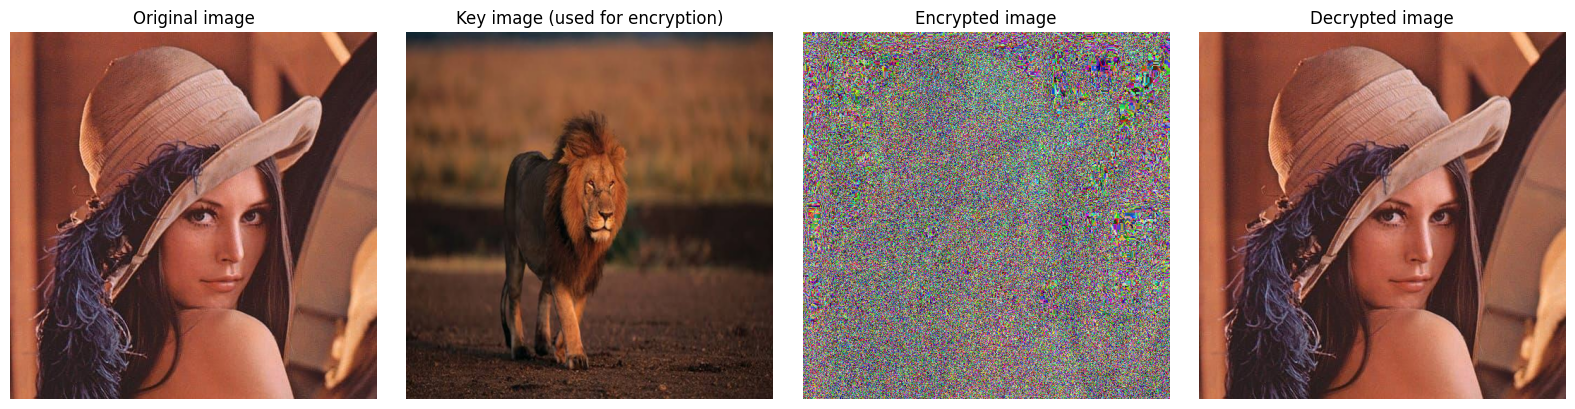

In [ ]:
#Result flow
plt.figure(figsize=(16, 4))

# 1. Original
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title("Original image")
plt.axis("off")

# 2. Key (display the resized RGB key used for encryption) (Bug 3)
plt.subplot(1, 4, 2)
plt.imshow(rgb_resized_key) # Changed from p_img_key to rgb_resized_key
plt.title("Key image (used for encryption)") # Clarified title
plt.axis("off")

# 3. Encrypted
plt.subplot(1, 4, 3)
plt.imshow(img_encrypted)
plt.title("Encrypted image")
plt.axis("off")

# 4. Decrypted
plt.subplot(1, 4, 4)
plt.imshow(img_recovered)
plt.title("Decrypted image")
plt.axis("off")

plt.tight_layout()
plt.show()

Entropy — randomness of encrypted image

MSE — difference between original and encrypted image

PSNR — another image-difference measure

NPCR — pixel-change rate

UACI — average intensity change
Encryption/decryption

time — performance

Exact recovery check — confirms decryption actually returns the original

In [ ]:
# METRICS
import time
# 1. ENTROPY
def entropy(image):
    pixels = image.flatten()

    histogram, _ = np.histogram(
        pixels,
        bins=256,
        range=(0, 256)
    )

    probability = histogram / len(pixels)
    probability = probability[probability > 0]

    return -np.sum(
        probability * np.log2(probability)
    )


# 2. MSE
def mse(image1, image2):

    difference = (
        image1.astype(np.float64)
        - image2.astype(np.float64)
    )

    return np.mean(difference ** 2)


# 3. PSNR
def psnr(image1, image2):

    mse_value = mse(image1, image2)

    if mse_value == 0:
        return float("inf")

    return 20 * np.log10(
        255 / np.sqrt(mse_value)
    )


# 4. NPCR
def npcr(image1, image2):

    if len(image1.shape) == 3:
        different_pixels = np.any(
            image1 != image2,
            axis=2
        )

        total_pixels = (
            image1.shape[0] *
            image1.shape[1]
        )
    else:
        different_pixels = image1 != image2
        total_pixels = image1.size

    return (
        np.sum(different_pixels)
        / total_pixels
        * 100
    )


# 5. UACI
def uaci(image1, image2):

    difference = np.abs(
        image1.astype(np.float64)
        - image2.astype(np.float64)
    )

    return (
        np.mean(difference)
        / 255
        * 100
    )


# 6. EXACT RECOVERY
def check_recovery(original, recovered):

    return np.array_equal(
        original,
        recovered
    )

# CALCULATE METRICS


entropy_value = entropy(img_encrypted)

mse_value = mse(
    rgb_img_orginal,
    img_encrypted
)

psnr_value = psnr(
    rgb_img_orginal,
    img_encrypted
)

npcr_value = npcr(
    rgb_img_orginal,
    img_encrypted
)

uaci_value = uaci(
    rgb_img_orginal,
    img_encrypted
)

recovery = check_recovery(
    rgb_img_orginal,
    img_recovered
)

# DISPLAY RESULTS

print("\n" + "=" * 50)
print("                ENCRYPTION METRICS")
print("=" * 50)

print(f"Entropy : {entropy_value:.4f} bits")
print(f"MSE     : {mse_value:.4f}")
print(f"PSNR    : {psnr_value:.4f} dB")
print(f"NPCR    : {npcr_value:.4f}%")
print(f"UACI    : {uaci_value:.4f}%")



print(f"\nEncryption Time : {encryption_time:.6f} ms")
print(f"Decryption Time : {decryption_time:.6f} ms")

print("\n" + "=" * 50)
print("                DECRYPTION TEST")
print("=" * 50)

if recovery:
    print("Recovery : SUCCESS")
    print("Original and recovered images are identical.")
else:
    print("Recovery : FAILED")

print("=" * 50)


                ENCRYPTION METRICS
Entropy : 7.7531 bits
MSE     : 8556.6166
PSNR    : 8.8078 dB
NPCR    : 100.0000%
UACI    : 29.8246%

Encryption Time : 15.116930 ms
Decryption Time : 5.177975 ms

                DECRYPTION TEST
Recovery : SUCCESS
Original and recovered images are identical.
